In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/Crop_recommendation.csv")

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
X = df.drop("label", axis=1).values
y = df["label"].values

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (2200, 7)
Target shape: (2200,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (1760, 7)
Testing samples: (440, 7)


In [5]:
class Node:
    
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

In [15]:
class DecisionTreeCART:

    def __init__(self, max_depth=6, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None


    # Gini Impurity
    def gini(self, y):

        classes = np.unique(y)
        impurity = 1

        for c in classes:
            p = np.sum(y == c) / len(y)
            impurity -= p ** 2

        return impurity


    # Split Dataset
    def split(self, X, y, feature, threshold):

        left_idx = X[:, feature] <= threshold
        right_idx = X[:, feature] > threshold

        return X[left_idx], X[right_idx], y[left_idx], y[right_idx]


    # Find Best Split
    def best_split(self, X, y):

        best_feature = None
        best_threshold = None
        best_gini = float("inf")

        n_features = X.shape[1]

        for feature in range(n_features):

            thresholds = np.unique(X[:, feature])

            for threshold in thresholds:

                X_left, X_right, y_left, y_right = self.split(X, y, feature, threshold)

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                gini_left = self.gini(y_left)
                gini_right = self.gini(y_right)

                weighted_gini = (
                    len(y_left) / len(y) * gini_left +
                    len(y_right) / len(y) * gini_right
                )

                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold


    # Majority Class
    def majority_class(self, y):

        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]


    # Build Tree
    def build_tree(self, X, y, depth=0):

        num_samples = len(y)
        num_classes = len(np.unique(y))

        if (
            depth >= self.max_depth or
            num_classes == 1 or
            num_samples < self.min_samples_split
        ):
            leaf_value = self.majority_class(y)
            return Node(value=leaf_value)

        feature, threshold = self.best_split(X, y)

        if feature is None:
            return Node(value=self.majority_class(y))

        X_left, X_right, y_left, y_right = self.split(X, y, feature, threshold)

        left_child = self.build_tree(X_left, y_left, depth + 1)
        right_child = self.build_tree(X_right, y_right, depth + 1)

        return Node(feature, threshold, left_child, right_child)


    # Train Model
    def fit(self, X, y):

        self.root = self.build_tree(X, y)


    # Predict One Sample
    def predict_sample(self, node, sample):

        if node.value is not None:
            return node.value

        if sample[node.feature] <= node.threshold:
            return self.predict_sample(node.left, sample)
        else:
            return self.predict_sample(node.right, sample)


    # Predict Dataset
    def predict(self, X):

        predictions = []

        for sample in X:
            predictions.append(self.predict_sample(self.root, sample))

        return np.array(predictions)

In [23]:
model = DecisionTreeCART(max_depth=7)

model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [24]:
y_pred = model.predict(X_test)

print("Predictions generated.")

Predictions generated.


In [25]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8431818181818181


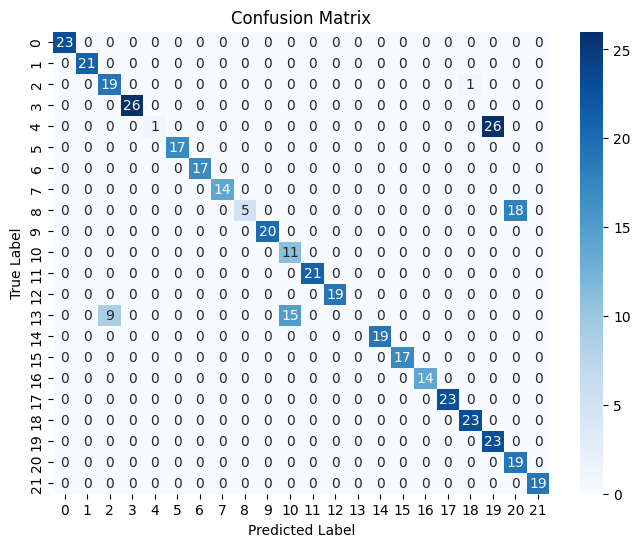

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()



In [11]:
print("Classification Report:\n")

print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.68      0.95      0.79        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      0.04      0.07        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       1.00      0.22      0.36        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.42      1.00      0.59        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       0.00      0.00      0.00        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
   

/home/prajwalmac/anaconda3/envs/project_venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/prajwalmac/anaconda3/envs/project_venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/prajwalmac/anaconda3/envs/project_venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(